In [1]:
%matplotlib widget

import os
import sys
import glob
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.widgets import RectangleSelector

PROJECT_PATH = os.path.abspath(os.path.join("..", ".."))
PIPELINE_PATH = os.path.join(PROJECT_PATH, "pipeline")
DATA_DIRECTORY = os.path.join(PROJECT_PATH, "data")

if PIPELINE_PATH not in sys.path:
    sys.path.append(PIPELINE_PATH)
    
from utils.paths import ICOS_CITIES_LEVEL_1, PIPELINE_DATA_DIRECTORY
from utils.os_functions import ensure_data_dir

assert (os.path.exists(ICOS_CITIES_LEVEL_1))
assert (os.path.exists(PIPELINE_DATA_DIRECTORY))

In [2]:
def annotate_month(
    df: pl.DataFrame,
    flag: np.ndarray,
    year: int,
    month: int,
    time_col="#Datetime",
    value_col="co2",
    ws_col="ws",
    wd_col="wd",
    # independent settings
    ws_min=None,                 # e.g. 0.5
    ws_max=2.0,                  # e.g. 2.0
    wd_ranges=((330, 30),),      # wrap-around supported
    # shading config
    shade_ws=True,
    shade_wd=True,
    ws_span_alpha=0.12,
    wd_span_alpha=0.12,
    ws_span_color="tab:blue",
    wd_span_color="tab:orange",
):
    def wd_mask_np(wd_deg: np.ndarray, ranges):
        wd = np.mod(wd_deg, 360.0)
        finite = np.isfinite(wd)
        out = np.zeros_like(wd, dtype=bool)
        for lo, hi in ranges:
            lo, hi = lo % 360.0, hi % 360.0
            if lo <= hi:
                out |= finite & (wd >= lo) & (wd <= hi)
            else:
                out |= finite & ((wd >= lo) | (wd <= hi))
        return out

    def ws_mask_np(ws: np.ndarray, ws_min=None, ws_max=None):
        out = np.isfinite(ws)
        if ws_min is not None:
            out &= (ws >= ws_min)
        if ws_max is not None:
            out &= (ws <= ws_max)
        return out

    def contiguous_true_spans(t_np, mask_np):
        mask_np = np.asarray(mask_np, dtype=bool)
        idx = np.flatnonzero(mask_np)
        if idx.size == 0:
            return []
        breaks = np.where(np.diff(idx) > 1)[0]
        starts = np.r_[idx[0], idx[breaks + 1]]
        ends   = np.r_[idx[breaks], idx[-1]]
        return [(t_np[s], t_np[e]) for s, e in zip(starts, ends)]
    
    # Close any existing figures from previous calls (useful in notebooks)
    plt.close('all')  # or: plt.close(plt.gcf()) if you only want to close the current one

    sub = (
        df.filter(
            (pl.col(time_col).dt.year() == year) &
            (pl.col(time_col).dt.month() == month)
        )
        .select(["row_id", time_col, value_col, ws_col, wd_col])
    )

    row_id  = sub["row_id"].to_numpy()
    time_np = sub[time_col].to_numpy()
    val_np  = sub[value_col].to_numpy()

    ws = np.asarray(sub[ws_col].to_numpy(), dtype=float)  # null-safe -> nan
    wd = np.asarray(sub[wd_col].to_numpy(), dtype=float)  # null-safe -> nan

    # Independent masks
    mask_ws = ws_mask_np(ws, ws_min=ws_min, ws_max=ws_max)
    mask_wd = wd_mask_np(wd, wd_ranges)

    # Main scatter colored by GLOBAL flag
    c = flag[row_id]
    fig, ax = plt.subplots(figsize=(12, 5))
    sc = ax.scatter(time_np, val_np, c=c, cmap="coolwarm", vmin=0, vmax=1, s=25)

    ax.set_title(f"Annotate {year}-{month:02d} (rectangle flags points)")
    ax.set_xlabel("Time")
    ax.set_ylabel(value_col)
    ax.set_xlim(time_np.min(), time_np.max())

    # Shade WS spans
    if shade_ws:
        for t0, t1 in contiguous_true_spans(time_np, mask_ws):
            ax.axvspan(t0, t1, alpha=ws_span_alpha, color=ws_span_color, lw=0)

    # Shade WD spans
    if shade_wd:
        for t0, t1 in contiguous_true_spans(time_np, mask_wd):
            ax.axvspan(t0, t1, alpha=wd_span_alpha, color=wd_span_color, lw=0)

    # Legend proxies (so spans appear in legend)
    handles = []
    labels = []
    if shade_ws:
        handles.append(plt.Line2D([0], [0], color=ws_span_color, lw=8, alpha=ws_span_alpha))
        labels.append("WS condition")
    if shade_wd:
        handles.append(plt.Line2D([0], [0], color=wd_span_color, lw=8, alpha=wd_span_alpha))
        labels.append("WD condition")
    if handles:
        ax.legend(handles, labels, loc="upper right", frameon=True)

    # Rectangle selector (manual flagging)
    def on_select(eclick, erelease):
        x0, x1 = eclick.xdata, erelease.xdata
        y0, y1 = eclick.ydata, erelease.ydata
        if x0 is None or x1 is None or y0 is None or y1 is None:
            return

        t0 = np.datetime64(mdates.num2date(x0).replace(tzinfo=None), "us")
        t1 = np.datetime64(mdates.num2date(x1).replace(tzinfo=None), "us")
        tmin, tmax = sorted([t0, t1])
        ymin, ymax = sorted([y0, y1])

        sel = (time_np >= tmin) & (time_np <= tmax) & (val_np >= ymin) & (val_np <= ymax)

        flag[row_id[sel]] = 1
        sc.set_array(flag[row_id])
        fig.canvas.draw_idle()

    rect = RectangleSelector(ax, on_select, useblit=False, button=[1], interactive=True)
    fig._rect_selector = rect  # keep alive

    plt.show()

In [3]:
def plot_direction_overlay(
    df,
    flag_value="H",
    ws_min=0.5,
    bin_width=10,
):
    # --- all data ---
    wd_all = np.asarray(df["wd"].to_numpy(), dtype=float)
    ws_all = np.asarray(df["ws"].to_numpy(), dtype=float)

    mask_all = np.isfinite(wd_all) & np.isfinite(ws_all) & (ws_all > ws_min)
    wd_all = wd_all[mask_all] % 360

    # --- flagged data ---
    df_f = df.filter(pl.col("Flag") == flag_value)
    wd_f = np.asarray(df_f["wd"].to_numpy(), dtype=float)
    ws_f = np.asarray(df_f["ws"].to_numpy(), dtype=float)

    mask_f = np.isfinite(wd_f) & np.isfinite(ws_f) & (ws_f > ws_min)
    wd_f = wd_f[mask_f] % 360

    bins = np.arange(0, 360 + bin_width, bin_width)

    fig, ax = plt.subplots(figsize=(8,4))

    ax.hist(
        wd_all,
        bins=bins,
        alpha=0.4,
        label="All data",
        edgecolor="black"
    )

    ax.hist(
        wd_f,
        bins=bins,
        alpha=0.7,
        label=f"Flag {flag_value}",
        edgecolor="black"
    )

    ax.set_xlim(0, 360)
    ax.set_xticks(np.arange(0, 361, 45))
    ax.set_xlabel("Wind direction (deg, from)")
    ax.set_ylabel("Count")
    ax.legend()
    ax.set_title("Directional occurrence: all vs flagged")

    plt.tight_layout()
    plt.show()

In [4]:
sites_lookup = {}
# load csv files
L1_filenames = glob.glob(os.path.join(ICOS_CITIES_LEVEL_1, '*.csv'))

for path in L1_filenames:  
    site = os.path.basename(path).split('_')[0]
    # add to dict
    sites_lookup[site] = path

# print available keys
print(sites_lookup.keys())

dict_keys(['BALR', 'HARR', 'RDIR', 'MAIR', 'PASR', 'GROR', 'BOGR', 'FELR', 'BLUT', 'TAUR', 'DLRR', 'NPLR', 'SENR', 'SCHR', 'SWMR', 'MAIR2', 'TUMR', 'FINR'])


In [5]:
# Manually select site to work on
site = 'GROR'

df = pl.read_csv(sites_lookup[site], skip_rows=44, has_header=True, separator=';', try_parse_dates=True).filter(pl.col("Year").is_in([2024,2025]))

# Ensure it's Polars Datetime (us) and add stable row id
df_site = df.with_row_index("row_id").with_columns(pl.col("#Datetime").cast(pl.Datetime("us"))).filter(pl.col("Flag") == "U")

# Global flags for the FULL df (persist across months)
flag = np.zeros(df.height, dtype=np.int8)

In [6]:
df

#Datetime,Year,Month,Day,Hour,Minute,Second,DecimalDate,co2,h2o,pressure,sensor_temperature,ws,wd,Flag
datetime[μs],i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,str
2024-02-14 00:00:30,2024,2,14,0,0,30,2024.120549,436.25,0.86,956.2,28.83,1.7,214.8,"""U"""
2024-02-14 00:01:30,2024,2,14,0,1,30,2024.120551,434.78,0.87,956.24,28.83,2.0,219.6,"""U"""
2024-02-14 00:02:30,2024,2,14,0,2,30,2024.120553,434.32,0.86,956.24,28.88,2.0,219.6,"""U"""
2024-02-14 00:03:30,2024,2,14,0,3,30,2024.120555,434.58,0.87,956.3,28.87,2.2,218.6,"""U"""
2024-02-14 00:04:30,2024,2,14,0,4,30,2024.120557,436.06,0.86,956.3,28.87,2.2,218.6,"""U"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2025-12-15 10:15:30,2025,12,15,10,15,30,2025.951988,575.87,0.62,954.85,23.48,null,null,"""U"""
2025-12-15 10:16:30,2025,12,15,10,16,30,2025.951989,506.89,0.63,954.84,23.63,null,null,"""U"""
2025-12-15 10:17:30,2025,12,15,10,17,30,2025.951991,505.89,0.63,954.84,23.75,null,null,"""U"""


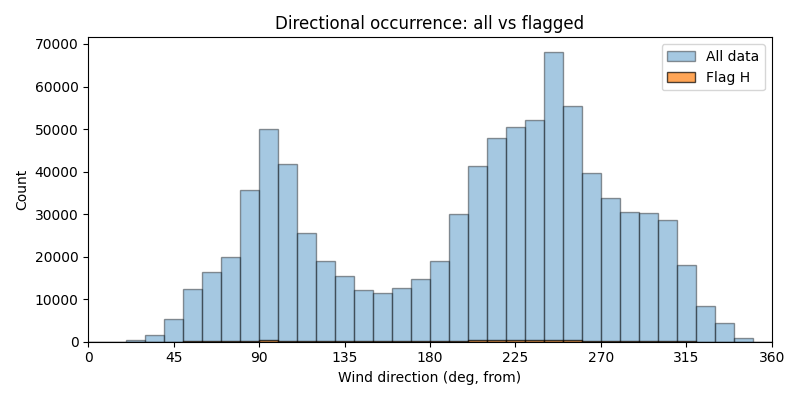

In [7]:
plot_direction_overlay(df, flag_value="H", ws_min=0.0, bin_width=10)

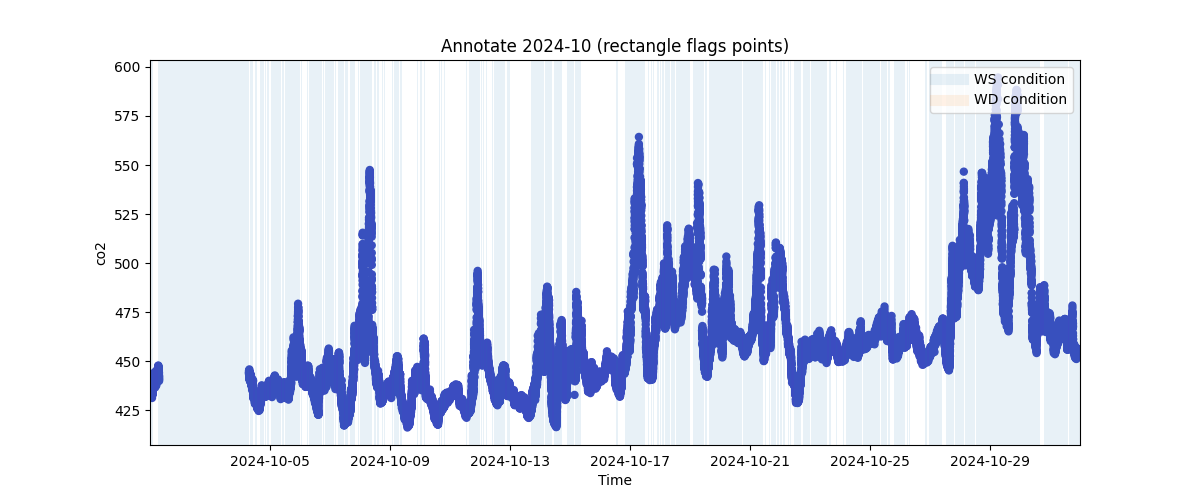

In [16]:
annotate_month(
    df_site, flag, 2024, 10,
    ws_min=0, ws_max=2.0,
    wd_ranges=((0,0),),
    ws_span_color="tab:blue",
    wd_span_color="tab:orange",
    ws_span_alpha=0.10,
    wd_span_alpha=0.10,
)

In [ ]:
# Add Manual_Flag column to original df
df_flagged = df.with_columns(pl.Series("Manual_Flag", flag))

# Percentage of flagged points
print("Percentage of flagged points:", 100 * df_flagged.get_column("Manual_Flag").sum() / df_flagged.height, "%")
df_flagged.filter(pl.col("Manual_Flag") != 0).tail()

In [ ]:
output_path = os.path.join(PIPELINE_DATA_DIRECTORY, "manual_flagging")
ensure_data_dir(output_path)
df_flagged.write_parquet(f"{output_path}/{site}_manually_flagged.parquet")